##### AutoGrad-The Why->Autograd lets you write math-like code and get correct gradients automatically, efficiently, and flexibly—at scale.

###### Autograd is core component of pytorch that provides automatic  differentiation for tensor operations. It enables gradient computation which is essential for training ml model using optimization alg lik gd

###### To see how autograd easily calculates gradients we will take some examples



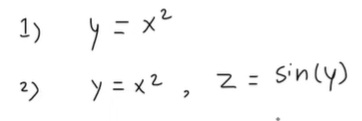

#####  lets calculate dy/dx for any given x for the eqn y=x^2

In [1]:
import torch

In [2]:
x=torch.tensor(3.0,requires_grad=True) #we only have one value in tensor, ie its a scalar.
#we set requires_grad=True so that pytorch understands that we want to find the derivatives and it tracks it

In [3]:
y=x**2

In [4]:
x

tensor(3., requires_grad=True)

In [5]:
y

tensor(9., grad_fn=<PowBackward0>)

In [6]:
#it performed the operation,, y=x**2, when we gave 3, it gave us 9, but it hasnt calculated the gradient yet
#the gradient for y=x**2 is 2x, so for x=3,2x=2*3=6, above it just performed the operations.
#so now lets see how pytorch calulates derivative

y.backward()
#we take y and use backward method to find its derivative,now to show the derivative value
x.grad # grad is an attribute

tensor(6.)

In [7]:
##Lets see another example using a nested function, we have 2 funtions
#y=x**2 ,z=sin(y), to calcuate gradient of this we need to use chain rule
#let see how to do that

x=torch.tensor(3.0,requires_grad=True)
y=x**2
z=torch.sin(y)

In [8]:
##### lets see x,y and z now

In [9]:
x

tensor(3., requires_grad=True)

In [10]:
y

tensor(9., grad_fn=<PowBackward0>)

In [11]:
z

tensor(0.4121, grad_fn=<SinBackward0>)

In [12]:
##### we need dz/dx, ie first we need to find dz/dy and dy/dx.and the multiplication of those values will give us dz/dx.
#these are the mathematical thing we need to know, but here, we can simply just use backward() method, that will give use dz/dx
z.backward()

In [13]:
x.grad

tensor(-5.4668)

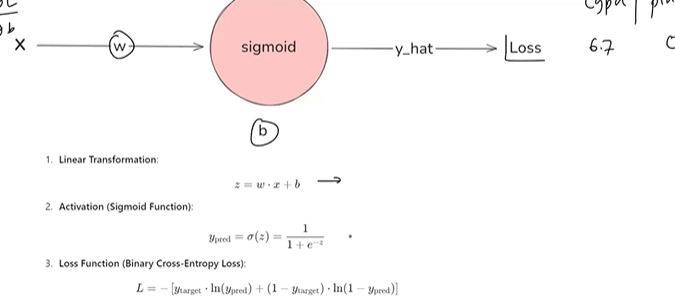

In [14]:
#### to understand more, lets use this  perceptron.
#first we will manually  find the dervatives and then use autograd to calculatte themand see how it makes work much easier

In [15]:
#### for the above perception, the L is dependent upon w,b
### we need to find dl/dw and dl/db
## for dl/dw= dl/d y_pred(or y_hat) * dypred/dz * dz/dw
## for dldb = dl/d y_pred(or y_hat) * dypred/dz * dz/db
#for time saving, here is the derivatives

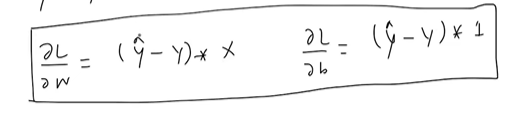

In [16]:
#### we will take a student with input_feature(cgpa) is 6.7 and target as 0 ie not selected

In [17]:
#first ,define a tensore

x=torch.tensor(6.7) #->input feature
y=torch.tensor(0.0) # true label

#for this example , we will take weights and bias 1 and 0
w=torch.tensor(1.0)
b=torch.tensor(0.0)

In [18]:
## to calculate the loss,  as shown in the diagram we will use Binary Cross-Entropy Loss  , we need a function for it
def binary_cross_entropy_loss(y_target,y_pred):#ie acttual value(actual target value, predicted value)
  #if y_pred becomes 0 or 1, then log(y_Pred=infinity which will cause math errors, to prevent that we willuse epsilon(a very small value)
  epsilon=1e-8
  #in order to prevent prediction from being 0, we  will force it be within epsilon
  pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
  #this will prevent it form being exactly 0 or 1 , so we will pass this insteaad of y_pred
  return -(y_target*torch.log(pred)+(1-y_target)*torch.log(1-pred))


In [19]:
## forward pass
z= w*x+b
y_pred=torch.sigmoid(z)

#compute loss
loss= binary_cross_entropy_loss(y,y_pred) # y is 0.0 , we defined its value above as tensor
loss


tensor(6.7012)

In [20]:
### next, we need to calculate all derivatives
# Derivatives:
# 1. dL/d(y_pred): Loss with respect to the prediction (y_pred)
dloss_dy_pred = (y_pred - y)/(y_pred*(1-y_pred))

# 2. dy_pred/dz: Prediction (y_pred) with respect to z (sigmoid derivative)
dy_pred_dz = y_pred * (1 - y_pred)

# 3. dz/dw and dz/db: z with respect to w and b
dz_dw = x  # dz/dw = x
dz_db = 1  # dz/db = 1 (bias contributes directly to z)

dL_dw = dloss_dy_pred * dy_pred_dz * dz_dw
dL_db = dloss_dy_pred * dy_pred_dz * dz_db

In [21]:
print(f"Manual Gradient of loss w.r.t weight (dw): {dL_dw}")
print(f"Manual Gradient of loss w.r.t bias (db): {dL_db}")

Manual Gradient of loss w.r.t weight (dw): 6.691762447357178
Manual Gradient of loss w.r.t bias (db): 0.998770534992218


##### now lets do it using pytorch

In [22]:

#first ,define a tensore

x=torch.tensor(6.7)
y=torch.tensor(0.0)


In [23]:

w=torch.tensor(1.0,requires_grad=True)
b=torch.tensor(0.0,requires_grad=True)

In [24]:
w

tensor(1., requires_grad=True)

In [25]:
b

tensor(0., requires_grad=True)

In [26]:
z=w*x+b
z

tensor(6.7000, grad_fn=<AddBackward0>)

In [27]:

y_pred= torch.sigmoid(z)
y_pred

tensor(0.9988, grad_fn=<SigmoidBackward0>)

In [28]:
loss=binary_cross_entropy_loss(y,y_pred)
loss

tensor(6.7012, grad_fn=<NegBackward0>)

In [29]:
loss.backward()

In [30]:
print(w.grad)
print(b.grad)

tensor(6.6918)
tensor(0.9988)


In [31]:
#### now lets see examples with vector inputs instead of just scalar


In [32]:
x=torch.tensor([1.0,2.0,3.0],requires_grad=True)

In [34]:
y= (x**2) .mean()

In [35]:
y

tensor(4.6667, grad_fn=<MeanBackward0>)

In [36]:
y.backward()

In [38]:
x.grad

tensor([0.6667, 1.3333, 2.0000])

##### clearing gradients


In [63]:
x=torch.tensor(2.0,requires_grad=True)


In [64]:
x


tensor(2., requires_grad=True)

In [69]:

y=x**2

In [70]:

y

tensor(4., grad_fn=<PowBackward0>)

In [71]:

y.backward()

In [72]:
x.grad

tensor(8.)

In [73]:
###the problem is gradients keep accumulating if we run the forward and backward multiple times, which aint desirable

In [74]:
## so before doing multiiple pass, we need tto clear the grads

In [77]:
##just simple chnage, do this
x.grad.zero_()

tensor(0.)

In [ ]:
### disabling gradient tracking, like when we are predicting, we dont need trackingg
#option requires_grad(_false),detach, torch.no_grad()->used most